# Deep Learning Overfitting Demo

This notebook demonstrates overfitting in neural networks using:
- **Part A:** MLP regression on `f(x) = sin(2πx)` — comparing shallow vs. deep architectures
- **Part B:** MLP classification on MNIST subset — demonstrating Dropout as regularization
- **Part C:** Network complexity vs. generalization error

**Note:** MNIST data will be automatically downloaded to `../data/` on first run (~12 MB).

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import torch

from src.data_generation import generate_polynomial_data, true_function
from src.deep_learning import (
    build_mlp,
    train_model,
    evaluate_network_complexity,
    load_mnist_subset,
)
from src.visualization import (
    plot_dl_synthetic_fits,
    plot_training_curves,
    plot_dropout_comparison,
    plot_network_complexity_comparison,
    save_figure,
)

torch.manual_seed(42)
np.random.seed(42)
print(f"PyTorch {torch.__version__}")

PyTorch 2.11.0+cpu


## Part A: MLP Regression on sin(2πx)

We use the same synthetic data as Notebook 01 and compare three MLP architectures:
- **Shallow** `[8]`: 1 hidden layer, 8 units — may underfit
- **Medium** `[32, 16]`: 2 hidden layers — good fit
- **Deep** `[128, 64, 32, 16]`: 4 hidden layers — prone to overfitting

This mirrors the polynomial degree experiment but with neural networks.

In [2]:
# Generate data (same as Notebook 01)
X_np, y_np = generate_polynomial_data(n_samples=30, noise_std=0.3, seed=42)
X_train = torch.tensor(X_np, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)

# Dense grid for smooth prediction curves
x_smooth_np = np.linspace(0, 1, 200)
x_smooth = torch.tensor(x_smooth_np, dtype=torch.float32).unsqueeze(1)

# Test data (noise-free ground truth)
X_test_np, y_test_np = generate_polynomial_data(n_samples=100, noise_std=0.0, seed=0)
X_test = torch.tensor(X_test_np, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1)

print(f"Training: {X_train.shape}, Test: {X_test.shape}")

Training: torch.Size([30, 1]), Test: torch.Size([100, 1])


[8] Shallow: 25 params, train_loss=0.0483, test_loss=0.0125


[32,16] Medium: 609 params, train_loss=0.0427, test_loss=0.0147


[128,64,32,16] Deep: 11137 params, train_loss=0.0042, test_loss=0.0471


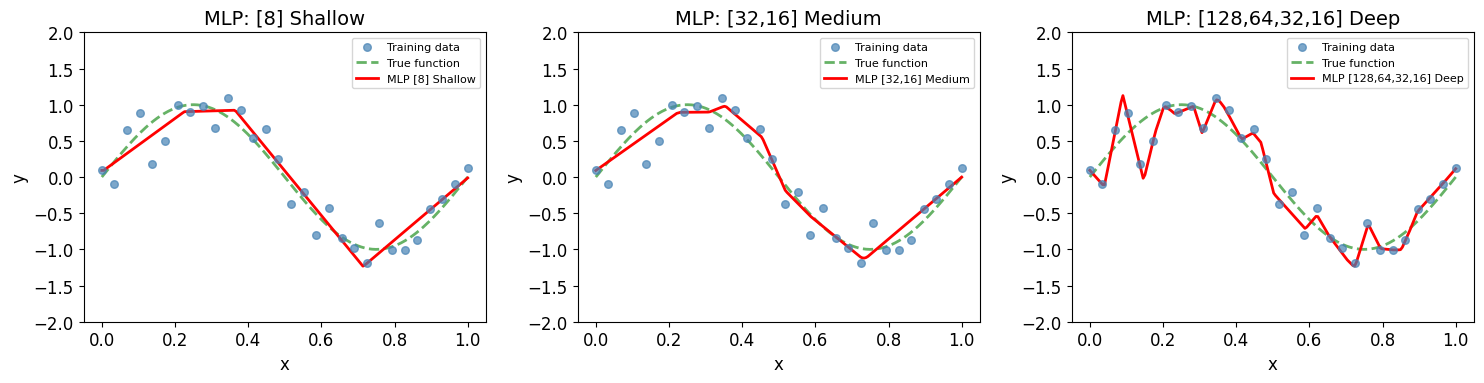

In [3]:
# Train three architectures
architectures = {"[8] Shallow": [8], "[32,16] Medium": [32, 16], "[128,64,32,16] Deep": [128, 64, 32, 16]}
predictions = {}

for label, arch in architectures.items():
    torch.manual_seed(42)
    model = build_mlp(input_dim=1, hidden_layers=arch, output_dim=1)
    result = train_model(model, X_train, y_train, X_test, y_test, epochs=2000, lr=0.01)
    model.eval()
    with torch.no_grad():
        pred = model(x_smooth).numpy().flatten()
    predictions[label] = pred
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{label}: {n_params} params, train_loss={result['train_losses'][-1]:.4f}, test_loss={result['test_losses'][-1]:.4f}")

fig = plot_dl_synthetic_fits(X_np, y_np, predictions, x_smooth_np, true_fn=true_function)
save_figure(fig, "../report/figures/dl_synthetic_overfitting.png")
fig

## Training Curves with Early Stopping

We train the deep network (4 layers) with early stopping (patience=50) to observe when
test loss starts increasing — the point where overfitting begins.

Stopped at epoch 174, best epoch: 74


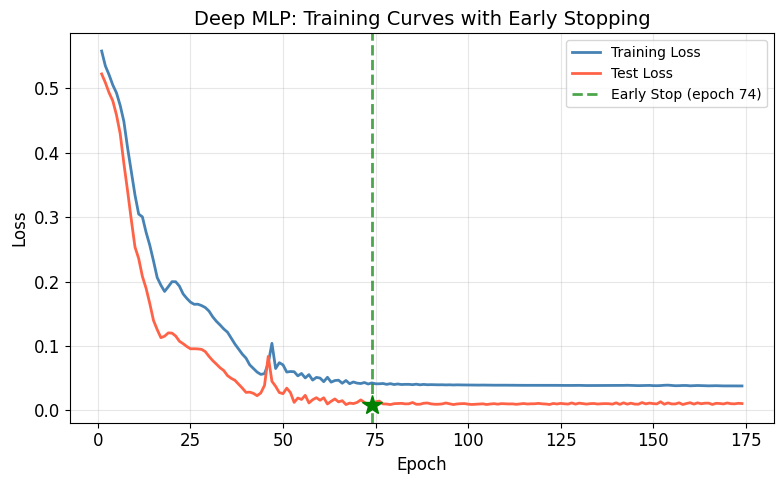

In [4]:
# Train deep model with early stopping
torch.manual_seed(42)
deep_model = build_mlp(input_dim=1, hidden_layers=[128, 64, 32, 16], output_dim=1)
deep_result = train_model(
    deep_model, X_train, y_train, X_test, y_test,
    epochs=2000, lr=0.01, patience=100,
)
print(f"Stopped at epoch {len(deep_result['train_losses'])}, best epoch: {deep_result['best_epoch'] + 1}")

fig = plot_training_curves(
    deep_result["train_losses"],
    deep_result["test_losses"],
    best_epoch=deep_result["best_epoch"],
    title="Deep MLP: Training Curves with Early Stopping",
)
save_figure(fig, "../report/figures/dl_training_curves.png")
fig

## Part B: MNIST Classification — Dropout Effect

We intentionally use a **small training subset (500 samples)** to trigger overfitting,
then show how Dropout (p=0.5) mitigates it.

MNIST data is downloaded automatically to `../data/` if not already present.

In [5]:
# Load MNIST subset (auto-downloads if needed)
X_mnist_train, y_mnist_train, X_mnist_test, y_mnist_test = load_mnist_subset(
    n_train=500, n_test=1000, seed=42, data_dir="../data",
)
print(f"MNIST Train: {X_mnist_train.shape}, Test: {X_mnist_test.shape}")
print(f"Classes: {torch.unique(y_mnist_train).tolist()}")

MNIST Train: torch.Size([500, 784]), Test: torch.Size([1000, 784])
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [6]:
# Train WITHOUT dropout
torch.manual_seed(42)
model_no_drop = build_mlp(input_dim=784, hidden_layers=[256, 128], output_dim=10, dropout_rate=0.0)
result_no_drop = train_model(
    model_no_drop, X_mnist_train, y_mnist_train, X_mnist_test, y_mnist_test,
    epochs=200, lr=0.001, task="classification", batch_size=64,
)
print(f"No Dropout — Final train loss: {result_no_drop['train_losses'][-1]:.4f}, "
      f"test loss: {result_no_drop['test_losses'][-1]:.4f}")

# Train WITH dropout
torch.manual_seed(42)
model_drop = build_mlp(input_dim=784, hidden_layers=[256, 128], output_dim=10, dropout_rate=0.5)
result_drop = train_model(
    model_drop, X_mnist_train, y_mnist_train, X_mnist_test, y_mnist_test,
    epochs=200, lr=0.001, task="classification", batch_size=64,
)
print(f"Dropout=0.5 — Final train loss: {result_drop['train_losses'][-1]:.4f}, "
      f"test loss: {result_drop['test_losses'][-1]:.4f}")

No Dropout — Final train loss: 0.0001, test loss: 0.8611


Dropout=0.5 — Final train loss: 0.0051, test loss: 0.8181


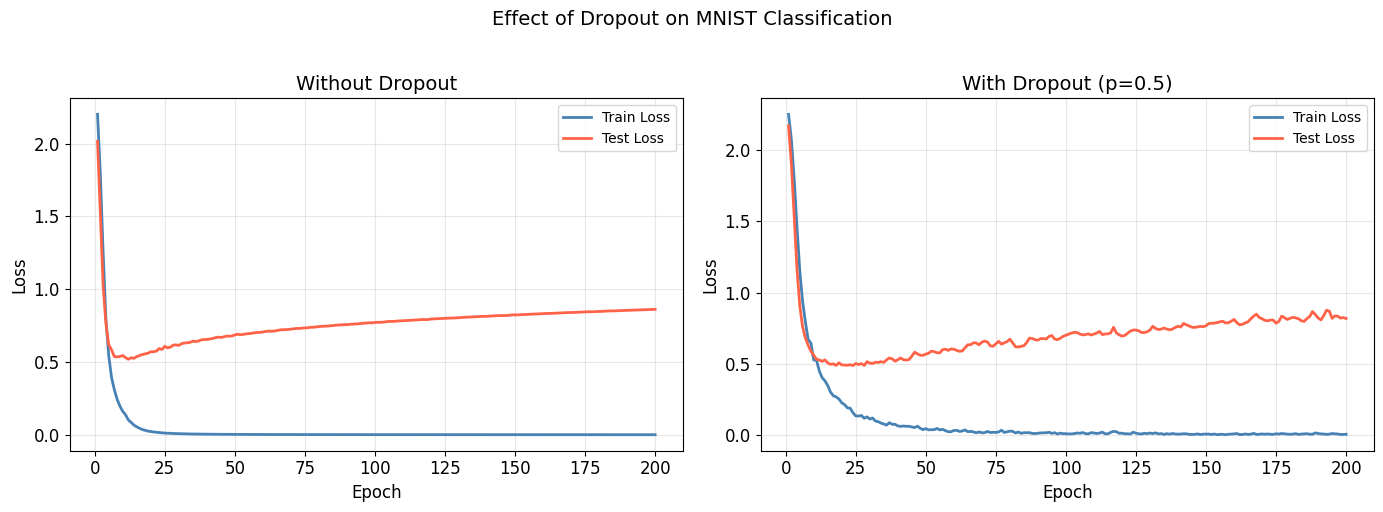

In [7]:
fig = plot_dropout_comparison(result_no_drop, result_drop)
save_figure(fig, "../report/figures/dl_dropout_effect.png")
fig

## Part C: Network Complexity vs. Generalization

We systematically increase network size and observe the classic U-shaped test error curve —
the neural network analogue of polynomial degree vs. test error.

            [4]:     13 params, test_loss=0.0193
            [8]:     25 params, test_loss=0.0118
           [16]:     49 params, test_loss=0.1571
        [32,16]:    609 params, test_loss=0.0115
        [64,32]:   2241 params, test_loss=0.0129
       [128,64]:   8577 params, test_loss=0.0137
   [256,128,64]:  41729 params, test_loss=0.0334


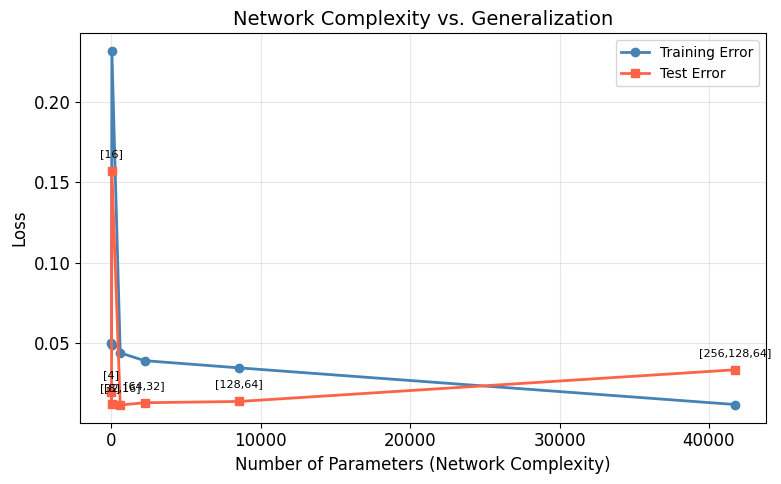

In [8]:
# Evaluate increasing network sizes on synthetic regression data
arch_list = [[4], [8], [16], [32, 16], [64, 32], [128, 64], [256, 128, 64]]
arch_labels = ["[4]", "[8]", "[16]", "[32,16]", "[64,32]", "[128,64]", "[256,128,64]"]

complexity_result = evaluate_network_complexity(
    X_train, y_train, X_test, y_test,
    architectures=arch_list, seed=42, epochs=1000, lr=0.01,
)

for label, pc, te in zip(arch_labels, complexity_result["param_counts"], complexity_result["test_errors"]):
    print(f"{label:>15s}: {pc:>6d} params, test_loss={te:.4f}")

fig = plot_network_complexity_comparison(
    complexity_result["param_counts"],
    complexity_result["train_errors"],
    complexity_result["test_errors"],
    arch_labels=arch_labels,
)
save_figure(fig, "../report/figures/dl_network_complexity.png")
fig